# Notebook 03 — Modèle GNN : GCN et GAT

**Objectif** : Implémenter, entraîner et comparer GCN et GAT sur la tâche de prédiction de rendements.

**Concepts clés** :
- GCN : agrégation uniforme des voisins
- GAT : agrégation pondérée par attention apprise
- Entraînement sans data leakage (split temporel)
- Visualisation des poids d'attention

**Référence** : Veličković et al. (2018) — Graph Attention Networks

In [1]:
import sys, os
project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams['figure.dpi'] = 120

from src.gnn_model import GCNModel, GATModel, GNNTrainer, prepare_targets

# Charger le graphe et les rendements
graph_data = torch.load('../data/static_graph.pt', weights_only=False)
returns    = pd.read_parquet('../data/returns.parquet')

print(f"Graphe : {graph_data.num_nodes} nœuds, {graph_data.edge_index.shape[1]//2} arêtes")
print(f"Features par nœud : {graph_data.x.shape[1]}")
print(f"Device disponible : {'cuda' if torch.cuda.is_available() else 'cpu'}")

Graphe : 28 nœuds, 350 arêtes
Features par nœud : 5
Device disponible : cpu


## 1. Préparation des cibles

La **cible** est le rendement cumulé sur les 5 prochains jours (1 semaine de trading).

**Attention au data leakage !** En finance, on ne peut jamais mélanger aléatoirement les données. Le split doit être strictement temporel : on entraîne sur le passé, on valide sur le futur.

In [2]:
# Préparer les cibles (rendements futurs sur 5 jours)
dates, targets = prepare_targets(returns, horizon=5, normalize=True)

print(f"Cibles : {targets.shape}  ({len(dates)} timesteps × {targets.shape[1]} actifs)")
print(f"Période : {dates[0].date()} → {dates[-1].date()}")

# Split temporel 80/20
split = int(len(targets) * 0.8)
print(f"\nSplit : {split} train | {len(targets)-split} test")
print("Rappel : JAMAIS de shuffle sur des données financières !")

Cibles : (1499, 28)  (1499 timesteps × 28 actifs)
Période : 2018-01-09 → 2023-12-21

Split : 1199 train | 300 test
Rappel : JAMAIS de shuffle sur des données financières !


## 2. Entraînement du GCN (niveau minimum)

GCNModel(
  (conv1): GCNConv(5, 64)
  (conv2): GCNConv(64, 32)
  (head): Linear(in_features=32, out_features=1, bias=True)
)
[GNNTrainer] Device : cpu
[GNNTrainer] Paramètres : 2,497
[GNNTrainer] Train: 1199 timesteps | Val: 300 timesteps
  Epoch    1/200 | Train loss: 0.001599 | Val loss: 0.008618
  Epoch   40/200 | Train loss: 0.000264 | Val loss: 0.008066
  Epoch   80/200 | Train loss: 0.000283 | Val loss: 0.008247
  Epoch  120/200 | Train loss: 0.000308 | Val loss: 0.008210
  Epoch  160/200 | Train loss: 0.000295 | Val loss: 0.008208
  Epoch  200/200 | Train loss: 0.000256 | Val loss: 0.008208

[GNNTrainer] ✓ Entraînement terminé | Meilleure val loss: 0.007411


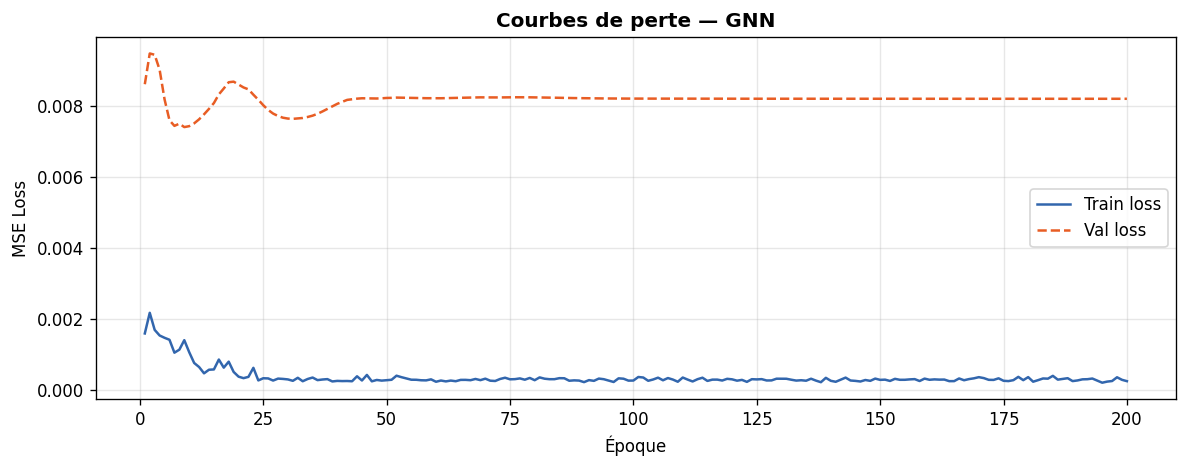

In [3]:
in_features = graph_data.x.shape[1]

gcn_model = GCNModel(
    in_channels  = in_features,
    hidden       = 64,
    out_channels = 1,
    dropout      = 0.3,
)
print(gcn_model)

gcn_trainer = GNNTrainer(gcn_model, lr=1e-3, weight_decay=1e-4)

gcn_trainer.fit(
    graph_data    = graph_data,
    targets       = targets,
    epochs        = 200,
    val_split     = 0.2,
    verbose_every = 40,
)

fig = gcn_trainer.plot_training()
plt.savefig('../data/07_gcn_training.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Entraînement du GAT (niveau bon/excellent)

Le GAT ajoute un mécanisme d'**attention** : chaque nœud apprend à quel point il doit "écouter" chacun de ses voisins. En finance, cela permet d'apprendre que AAPL doit plus écouter MSFT que HON (même si les deux sont voisins).

GATModel(
  (gat1): GATConv(5, 64, heads=4)
  (gat2): GATConv(256, 64, heads=1)
  (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (head): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=1, bias=True)
  )
)
[GNNTrainer] Device : cpu
[GNNTrainer] Paramètres : 21,377
[GNNTrainer] Train: 1199 timesteps | Val: 300 timesteps
  Epoch    1/200 | Train loss: 0.200660 | Val loss: 1.569803
  Epoch   40/200 | Train loss: 0.010013 | Val loss: 0.045655
  Epoch   80/200 | Train loss: 0.032904 | Val loss: 0.018916
  Epoch  120/200 | Train loss: 0.008895 | Val loss: 0.004540
  Epoch  160/200 | Train loss: 0.004695 | Val loss: 0.004948
  Epoch  200/200 | Train loss: 0.001042 | Val loss: 0.004971

[GNNTrainer] ✓ Entraînement terminé | Meilleure val loss: 0.003892


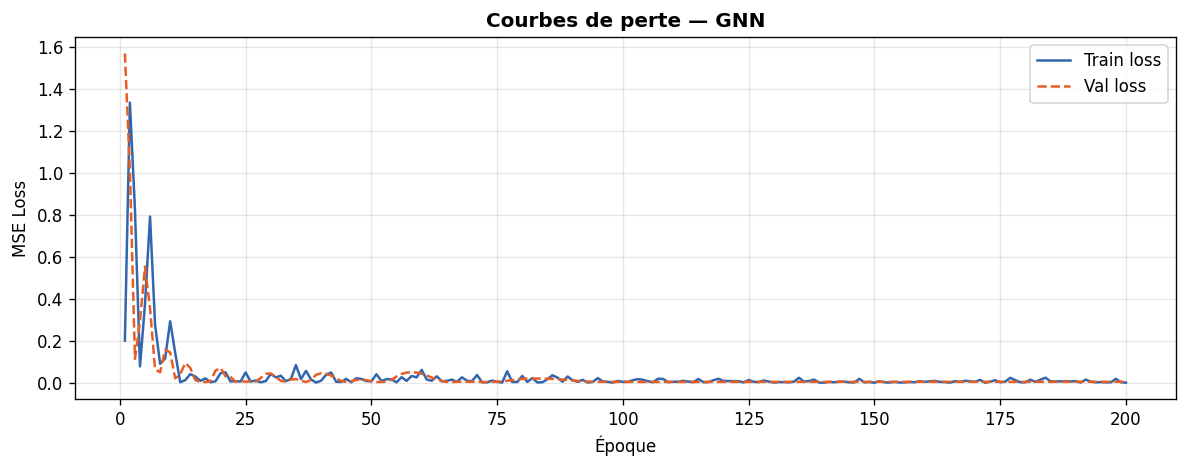

In [4]:
gat_model = GATModel(
    in_channels  = in_features,
    hidden       = 64,
    out_channels = 1,
    heads        = 4,
    dropout      = 0.3,
)
print(gat_model)

gat_trainer = GNNTrainer(gat_model, lr=1e-3, weight_decay=1e-4)

gat_trainer.fit(
    graph_data    = graph_data,
    targets       = targets,
    epochs        = 200,
    val_split     = 0.2,
    verbose_every = 40,
)

fig = gat_trainer.plot_training()
plt.savefig('../data/08_gat_training.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Prédictions et comparaison GCN vs GAT

── Top 10 actifs recommandés par le GAT ──
Ticker  Score GCN  Score GAT  Rang GCN  Rang GAT
   NKE  -0.005890   0.053062         2         1
  INTC  -0.005987   0.052966         3         2
   WMT  -0.005468   0.052364         1         3
   DIS  -0.006114   0.051875         7         4
  MSFT  -0.006281   0.051373         9         5
  AAPL  -0.006281   0.051373         8         6
    PG  -0.006027   0.051285         4         7
   MCD  -0.006493   0.050290        19         8
     V  -0.006493   0.050290        23         8
   IBM  -0.006493   0.050290        18        10


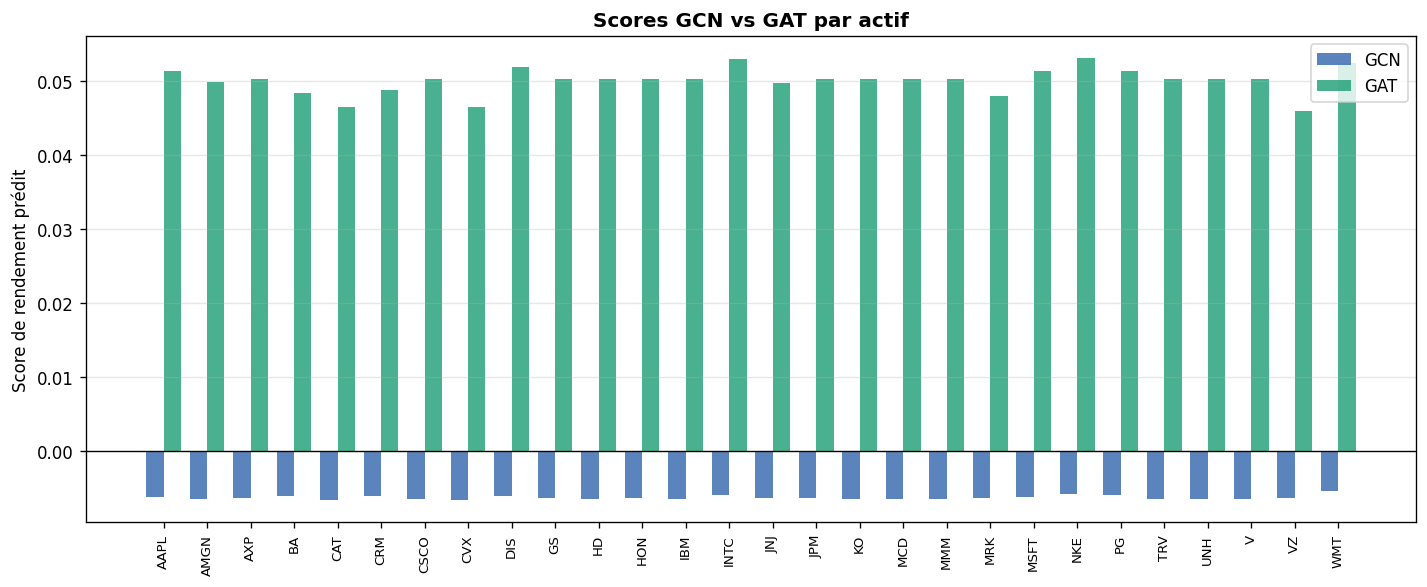

In [5]:
tickers = list(returns.columns)

gcn_preds = gcn_trainer.predict(graph_data)
gat_preds = gat_trainer.predict(graph_data)

# Tableau comparatif des scores par actif
pred_df = pd.DataFrame({
    'Ticker'        : tickers,
    'Score GCN'     : gcn_preds,
    'Score GAT'     : gat_preds,
    'Rang GCN'      : pd.Series(gcn_preds).rank(ascending=False).astype(int).values,
    'Rang GAT'      : pd.Series(gat_preds).rank(ascending=False).astype(int).values,
}).sort_values('Score GAT', ascending=False)

print("── Top 10 actifs recommandés par le GAT ──")
print(pred_df.head(10).to_string(index=False))

# Visualisation : comparaison des scores
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(tickers))
ax.bar(x - 0.2, gcn_preds, 0.4, label='GCN', color='#3266ad', alpha=0.8)
ax.bar(x + 0.2, gat_preds, 0.4, label='GAT', color='#1D9E75', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(tickers, rotation=90, fontsize=8)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Score de rendement prédit')
ax.set_title('Scores GCN vs GAT par actif', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('../data/09_gcn_vs_gat_scores.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Sauvegarde des modèles et prédictions

In [ ]:
gcn_trainer.save('../data/gcn_model.pt')
gat_trainer.save('../data/gat_model.pt')

np.save('../data/gcn_predictions.npy', gcn_preds)
np.save('../data/gat_predictions.npy', gat_preds)

print("✓ Modèles et prédictions sauvegardés")

[GNNTrainer] Modèle sauvegardé : ../data/gcn_model.pt
[GNNTrainer] Modèle sauvegardé : ../data/gat_model.pt
✓ Modèles et prédictions sauvegardés
Prochain notebook : 04_portfolio_backtest.ipynb
